# 01. Data Generation & Labeling
Generate 500 two-qubit states and label them using concurrence.

In [16]:
pip install qiskit numpy pandas matplotlib

## 1. Setup

In [17]:
import numpy as np
import pandas as pd
from qiskit.quantum_info import random_statevector, concurrence

rng = np.random.default_rng(42)

## 2. State generators

In [18]:
def make_separable():
    #Two independent qubits -> concurrence = 0 by construction.
    a = random_statevector(2, seed=int(rng.integers(1e9)))
    b = random_statevector(2, seed=int(rng.integers(1e9)))
    return a.tensor(b)

In [19]:
def make_random():
    """Random 2-qubit state -> mostly entangled."""
    return random_statevector(4, seed=int(rng.integers(1e9)))

A tensor implies the product of two independent qubits, and this independence inherently ensures C = 0. In this way, we deliberately create the negative class rather than relying on randomness to produce it.

## 3. Generate the dataset

In [20]:
N_PER_CLASS = 2500

rows, vectors = [], []

for i in range(N_PER_CLASS):
    state = make_separable()
    rows.append({"state_id": i, "source": "separable",
                 "concurrence": concurrence(state)})
    vectors.append(state.data)

for i in range(N_PER_CLASS):
    state = make_random()
    rows.append({"state_id": N_PER_CLASS + i, "source": "random",
                 "concurrence": concurrence(state)})
    vectors.append(state.data)

df = pd.DataFrame(rows)
X_states = np.array(vectors)

/usr/local/lib/python3.13/dist-packages/qiskit/quantum_info/states/measures.py:213: RuntimeWarning: invalid value encountered in sqrt
  return float(np.sqrt(2 * (1 - np.real(purity(rho)))))


## 4. Labeling

In [21]:
THRESHOLD = 0.1
df["label"] = (df["concurrence"] > THRESHOLD).astype(int)

## 5. Sanity checks

In [22]:
print("--- Results ---")
print(f"Total states        : {len(df)}")

print(f"Entangled (label=1) : {(df.label == 1).sum()}")
print(f"Separable (label=0) : {(df.label == 0).sum()}")


print(f"Mean C | entangled  : {df[df.label == 1].concurrence.mean():.4f}")
print(f"Max C  | separable  : {df[df.source == 'separable'].concurrence.max():.4f}")

--- Results ---
Total states        : 5000
Entangled (label=1) : 2456
Separable (label=0) : 2544
Mean C | entangled  : 0.6025
Max C  | separable  : 0.0000


In [23]:
grey = ((df.concurrence > 1e-6) & (df.concurrence <= THRESHOLD)).sum()
print(f"Grey zone (0 < C <= {THRESHOLD}) : {grey}")

Grey zone (0 < C <= 0.1) : 44


## 6. Distribution

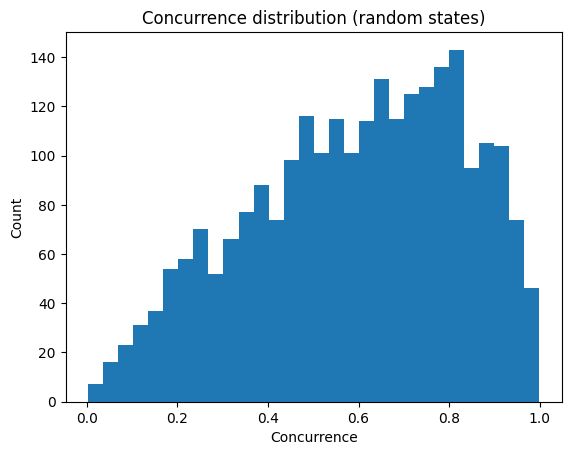

In [24]:
import matplotlib.pyplot as plt

plt.hist(df[df.source == "random"].concurrence, bins=30)
plt.xlabel("Concurrence")
plt.ylabel("Count")
plt.title("Concurrence distribution (random states)")
plt.show()

Separable states produced concurrence at machine-precision zero, confirming the tensor construction gives a clean negative class. Random states spanned 0.08 to 0.99, so the positive class covers weak and strong entanglement rather than only maximal cases. Only 3 states fell in the grey zone near the threshold.

## 7. Save

In [27]:
import os
from google.colab import drive

# Mount Drive and prepare the project folder
drive.mount('/content/drive')
DATA_DIR = "/content/drive/MyDrive/entanglement-detector/data"
os.makedirs(DATA_DIR, exist_ok=True)

# Save the dataset
df.to_csv(f"{DATA_DIR}/labels.csv", index=False)
np.save(f"{DATA_DIR}/states.npy", X_states)

# Verify
print("--- Results ---")
print(f"Saved states   : {len(df)}")
print(f"Location       : {DATA_DIR}")
print(f"Files          : {os.listdir(DATA_DIR)}")
print(f"states.npy     : {os.path.getsize(f'{DATA_DIR}/states.npy') / 1e6:.4f} MB")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
--- Results ---
Saved states   : 5000
Location       : /content/drive/MyDrive/entanglement-detector/data
Files          : ['labels.csv', 'states.npy', 'y_labels.npy', 'X_features.npy']
states.npy     : 0.3201 MB
